# **PROYECTO: Data Preprocesing & EDA**

---



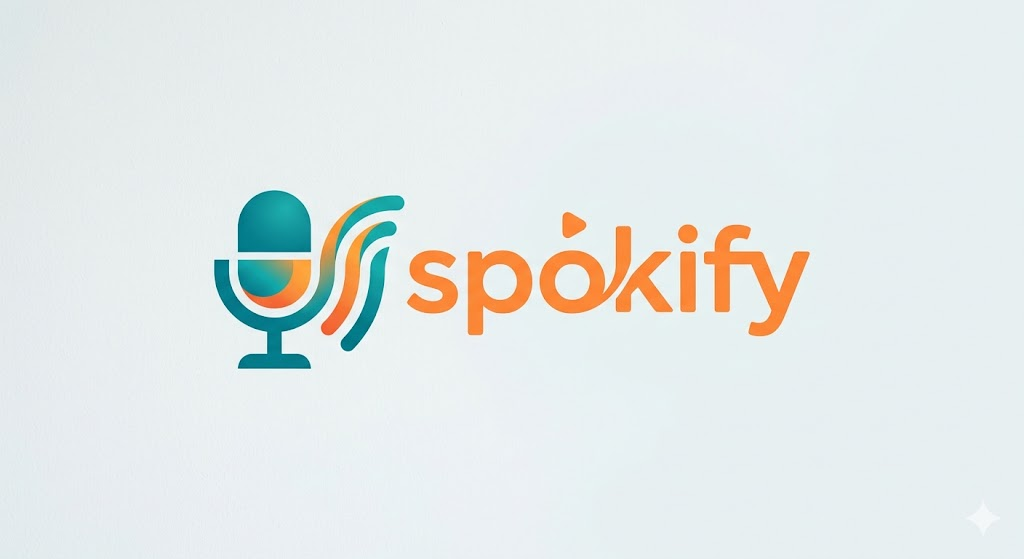


---


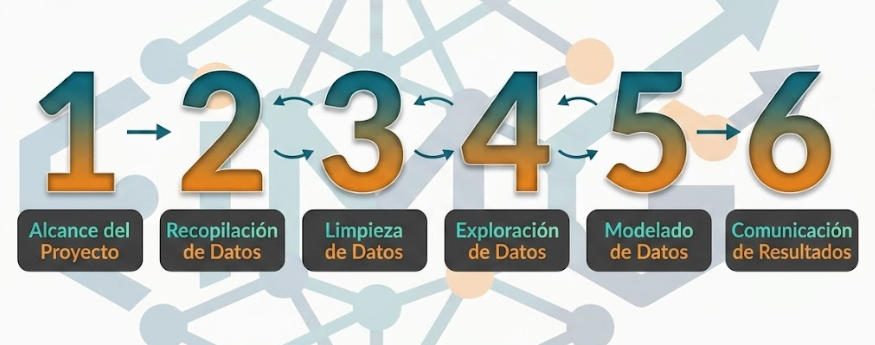

## 1. Alcance del Proyecto (Scope)

Nuestro plan consiste en utilizar una técnica de aprendizaje supervisado para predecir qué clientes tienen más probabilidades de cancelar su suscripción utilizando **los datos de los últimos tres meses de los clientes, que incluyen el historial de suscripción y de escucha (historial musical)**.

## **2. Recopilación de Datos (Gather Data)**


Lee los siguientes archivos en Python:
* Datos del cliente: *spokify_clientes _musical.csv*
* Historial de listados: *spokify_historico_musical.xlsx*

In [1]:
import pandas as pd

In [2]:
# Leer los datos del cliente
clientes = pd.read_csv('spokify_clientes _musical.csv')
clientes.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [3]:
# Leer Historial musical
historico_musical = pd.read_excel('spokify_historico_musical.xlsx', sheet_name = 0)
historico_musical.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


### **Hint**: ¿Dónde se pueden encontrar datos del historial musical más allá de los identificadores?

In [4]:
# Leer los datos de Audio
audio = pd.read_excel('spokify_historico_musical.xlsx', sheet_name = 1)
audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [5]:
# Leer los datos de la sesión
sesion = pd.read_excel('spokify_historico_musical.xlsx', sheet_name = 2)
sesion.head()

,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


## 3. Limpieza de Datos (Clean Data)

### a. Convertir tipos de datos

Verifique los tipos de datos de las tablas y conviértalos a valores numéricos y de fecha y hora según sea necesario.

In [6]:
# Comprobar los tipos de datos
print(clientes.dtypes)
print(historico_musical.dtypes)
print(audio.dtypes)
print(sesion.dtypes)

Customer ID           int64
Customer Name        object
Email                object
Member Since         object
Subscription Plan    object
Subscription Rate    object
Discount?            object
Cancellation Date    object
dtype: object
Customer ID     int64
Session ID      int64
Audio Order     int64
Audio ID        int64
Audio Type     object
dtype: object
ID            object
Name          object
Genre         object
Popularity     int64
dtype: object
Session ID                      int64
Session Log In Time    datetime64[ns]
dtype: object


In [7]:
clientes.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,3/13/23,Basic (Ads),$2.99,NaN,NaN
1,5002,Aria Keys,Email: melodious.aria@email.edu,3/13/23,NaN,$2.99,NaN,NaN
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,3/13/23,NaN,$2.99,NaN,6/1/23
3,5267,Rock Bassett,Email: groovy.rock@email.com,3/20/23,Basic (Ads),$2.99,NaN,NaN
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,3/20/23,NaN,$2.99,NaN,NaN


In [8]:
# Convertir objetos en campos numéricos y de fecha-hora.
clientes['Member Since'] = pd.to_datetime(clientes['Member Since']) # format='%d/%m/%Y'
clientes['Subscription Rate'] = pd.to_numeric(clientes['Subscription Rate'].str.replace('$',''))
clientes['Cancellation Date'] = pd.to_datetime(clientes['Cancellation Date'])

/tmp/ipykernel_12078/2466872374.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clientes['Member Since'] = pd.to_datetime(clientes['Member Since']) # format='%d/%m/%Y'
/tmp/ipykernel_12078/2466872374.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clientes['Cancellation Date'] = pd.to_datetime(clientes['Cancellation Date'])


Códigos comunes de formato de fecha.
Puedes construir la cadena format exacta que necesitas usando estos códigos comunes:

* **%Y**: Año de 4 dígitos (ej., 2023)

* **%y**: Año de 2 dígitos (ej., 23)

* **%m**: Mes de 2 dígitos (01 al 12)

* **%d**: Día de 2 dígitos (01 al 31)

* **%H**: Hora en formato de 24 horas (00 al 23)

* **%M**: Minuto (00 al 59)

* **%S**: Segundo (00 al 59)

Por ejemplo, una fecha como 25-10-2023 14:30:00 usaría format='%d-%m-%Y %H:%M:%S'

In [9]:
clientes.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT


In [10]:
# Comprobar nuevamente los tipos de datos
print(clientes.dtypes)

Customer ID                   int64
Customer Name                object
Email                        object
Member Since         datetime64[ns]
Subscription Plan            object
Subscription Rate           float64
Discount?                    object
Cancellation Date    datetime64[ns]
dtype: object


### b. Resolver problemas de datos

Verifique si hay datos faltantes, texto inconsistente y errores tipográficos, datos duplicados y valores atípicos (outliers).

#### i. Datos faltantes (Missing Data)

In [11]:
# Busque valores NaN en los datos.
print(clientes.info())
print(historico_musical.info())
print(audio.info())
print(sesion.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  25 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          7 non-null      object        
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 2.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer ID  505 non-null    int64 
 1   Session ID   505 non-null    i

In [12]:
# La tabla clientes tiene valores nulos en los campos: Subscription Plan, Discount? y Cancellation Date
print(clientes.info())
clientes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  25 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          7 non-null      object        
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 2.0+ KB
None


,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT


In [13]:
# Consulta a la columna: 'Subscription Plan': todos los registros 'Subscription Plan' tipo NaN cuestan $2.99 (observación)
clientes[clientes['Subscription Plan'].isna()]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,NaN,2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,NaN,2.99,NaN,2023-06-01
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,NaN,2.99,NaN,NaT
5,5404,Jazz Saxton,Email: jazzy.sax@email.com,2023-03-20,NaN,2.99,NaN,2023-06-03
11,5827,Rhythm Franklin,Email: rhythmic.franklin@email.edu,2023-03-28,NaN,2.99,NaN,NaT


In [14]:
# Consultar las tarifas unicas de Subscription Rate (Catalogo de planes de suscripciones).
clientes[['Subscription Plan','Subscription Rate']].drop_duplicates()

,Subscription Plan,Subscription Rate
0,Basic (Ads),2.99
1,NaN,2.99
6,Premium (No Ads),9.99
15,Premium (No Ads),99.99
21,Premium (No Ads),7.99


In [15]:
# # Parece que la tarifa de $2.99 ​​es para el plan Básico (Basic (Ads))
# Así que seria correcto completar los valores faltantes del Plan de suscripción con: Basic (Ads).
clientes['Subscription Plan'] = clientes['Subscription Plan'].fillna('Basic (Ads)')
clientes.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,NaN,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,NaN,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,NaN,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,NaN,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,NaN,NaT


In [16]:
# Notar la diferencia:
clientes[['Subscription Plan','Subscription Rate']].drop_duplicates()

,Subscription Plan,Subscription Rate
0,Basic (Ads),2.99
6,Premium (No Ads),9.99
15,Premium (No Ads),99.99
21,Premium (No Ads),7.99


In [17]:
# Tratar ahora la columna: Discount?
clientes['Discount?'].value_counts()

,count
Discount?,
Yes,7


In [18]:
import numpy as np
clientes['Discount?'] = np.where(clientes['Discount?'] == 'Yes',1,0)
clientes.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [19]:
clientes['Discount?'].value_counts()

,count
Discount?,
0,23
1,7


In [20]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        30 non-null     int64         
 1   Customer Name      30 non-null     object        
 2   Email              30 non-null     object        
 3   Member Since       30 non-null     datetime64[ns]
 4   Subscription Plan  30 non-null     object        
 5   Subscription Rate  30 non-null     float64       
 6   Discount?          30 non-null     int64         
 7   Cancellation Date  13 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(2), object(3)
memory usage: 2.0+ KB


#### ii. Texto inconsistente y errores tipográficos

In [21]:
# Buscar inconsistencias en el texto y errores tipográficos.
clientes.describe()

,Customer ID,Member Since,Subscription Rate,Discount?,Cancellation Date
count,30.000000,30,30.000000,30.000000,13
mean,6276.333333,2023-04-10 06:24:00,8.556667,0.233333,2023-06-01 16:36:55.384615424
min,5001.000000,2023-03-13 00:00:00,2.990000,0.000000,2023-06-01 00:00:00
25%,5759.500000,2023-03-23 12:00:00,2.990000,0.000000,2023-06-01 00:00:00
50%,6196.000000,2023-04-05 12:00:00,2.990000,0.000000,2023-06-02 00:00:00
75%,6823.500000,2023-05-01 00:00:00,7.990000,0.000000,2023-06-02 00:00:00
max,7583.000000,2023-05-16 00:00:00,99.990000,1.000000,2023-06-03 00:00:00
std,814.255587,NaN,17.517840,0.430183,NaN


In [22]:
# Revisar el valor 99.99 parece un error tipográfico
clientes[clientes['Subscription Rate'] > 6.99]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
6,5581,Reed Sharp,Email: sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT
7,5759,Carol Kingbird,Email: songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02
8,5761,Sonata Nash,Email: musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,0,NaT
12,6029,Chord Campbell,Email: campbell.chordify@email.com,2023-03-29,Premium (No Ads),9.99,0,2023-06-02
14,6163,Melody Parks,Email: park.of.melodies@email.com,2023-04-05,Premium (No Ads),9.99,0,NaT
15,6229,Symphony Rhodes,Email: rhodes.symphony@email.com,2023-04-06,Premium (No Ads),99.99,0,2023-06-02
21,6822,Kiki Keys,Email: kiki.keys.piano@email.com,2023-05-01,Premium (No Ads),7.99,1,NaT
22,6824,Greta Groove,Email: groovy.greta@email.com,2023-05-01,Premium (No Ads),7.99,1,2023-06-02
23,7087,Harmony Heart,Email: heartfelt.harmony@email.com,2023-05-01,Premium (No Ads),7.99,1,2023-06-02
25,7224,Melody Fitzgerald,Email: fitzgerald.melody@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01


In [23]:
# Corregir el error tipográfico 99.99
clientes.iloc[15, 5] = 9.99

In [24]:
print(clientes.iloc[15,5])

9.99


In [25]:
# Revisar la data del historico musical
historico_musical.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [26]:
# Contar registros por categoria de la columna: Audio Type
historico_musical['Audio Type'].value_counts()

,count
Audio Type,
Song,463
Podcast,42


In [27]:
# Mira los datos de audio
audio.head()

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop Music,5
3,Song-104,Glowing Hearts,Pop Music,10
4,Song-105,Pop Rocks,Pop Music,52


In [28]:
audio['Genre'].value_counts()

,count
Genre,
Pop Music,3
Comedy,3
Hip Hop,3
Country,2
Pop,2
Jazz,2
True Crime,2


In [29]:
# Pop y Pop Music deberían asignarse al mismo valor: Pop
audio.Genre = np.where(audio.Genre == 'Pop Music', 'Pop', audio.Genre)
audio

,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop,5
3,Song-104,Glowing Hearts,Pop,10
4,Song-105,Pop Rocks,Pop,52
5,Song-106,My Old Dog and My True Love,Country,23
6,Song-107,Dirt Road Romance,Country,30
7,Song-108,Chase the Dream,Hip Hop,4
8,Song-109,Rise Above,Hip Hop,9
9,Song-110,Boss Moves,Hip Hop,28


#### iii. Filas duplicadas

In [30]:
# Buscar filas duplicadas
clientes[clientes.duplicated()]

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date


In [31]:
historico_musical[historico_musical.duplicated()]

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type


In [32]:
audio[audio.duplicated()]

,ID,Name,Genre,Popularity


In [33]:
sesion[sesion.duplicated()]

,Session ID,Session Log In Time


#### iv. Valores atípicos (Outliers)

In [34]:
# Busque valores atípicos
clientes.describe()

,Customer ID,Member Since,Subscription Rate,Discount?,Cancellation Date
count,30.000000,30,30.000000,30.000000,13
mean,6276.333333,2023-04-10 06:24:00,5.556667,0.233333,2023-06-01 16:36:55.384615424
min,5001.000000,2023-03-13 00:00:00,2.990000,0.000000,2023-06-01 00:00:00
25%,5759.500000,2023-03-23 12:00:00,2.990000,0.000000,2023-06-01 00:00:00
50%,6196.000000,2023-04-05 12:00:00,2.990000,0.000000,2023-06-02 00:00:00
75%,6823.500000,2023-05-01 00:00:00,7.990000,0.000000,2023-06-02 00:00:00
max,7583.000000,2023-05-16 00:00:00,9.990000,1.000000,2023-06-03 00:00:00
std,814.255587,NaN,3.058998,0.430183,NaN


In [35]:
historico_musical.describe()

,Customer ID,Session ID,Audio Order,Audio ID
count,505.000000,505.000000,505.000000,505.000000
mean,6112.247525,105225.554455,4.138614,112.063366
std,832.861221,3625.879577,2.669008,24.670285
min,5001.000000,100520.000000,1.000000,101.000000
25%,5267.000000,101925.000000,2.000000,103.000000
50%,6029.000000,105116.000000,4.000000,105.000000
75%,6822.000000,109654.000000,6.000000,109.000000
max,7583.000000,111333.000000,15.000000,205.000000


In [36]:
audio.describe()

,Popularity
count,17.000000
mean,21.058824
std,23.381271
min,1.000000
25%,4.000000
50%,10.000000
75%,28.000000
max,80.000000


In [37]:
sesion.describe()

,Session ID,Session Log In Time
count,90.000000,90
mean,105619.788889,2023-04-27 08:18:34.000000512
min,100520.000000,2023-03-13 14:14:00
25%,102149.000000,2023-04-05 21:21:30
50%,105390.500000,2023-05-03 20:03:00
75%,109658.250000,2023-05-18 22:17:30
max,111333.000000,2023-05-31 06:03:00
std,3616.208569,NaN


### c. Crear nuevas columnas

Crea dos nuevas columnas que serán útiles para el análisis exploratorio de datos (AED/EDA) y el modelado:
* Cancelled: indica si un cliente canceló o no
* Email: elimina "Email:" de las direcciones de correo electrónico

In [38]:
clientes.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT


In [39]:
# Crea una columna llamada 'Cancelled'.
clientes['Cancelled'] = np.where(clientes ['Cancellation Date'].notna(), 1, 0)
clientes.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,Email: harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,Email: melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,Email: rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,Email: groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,Email: beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


In [40]:
# Cree una columna 'Email' actualizada sin la parte Email.
clientes['Email'] = clientes.Email.str[6:]
clientes.head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


## 4. EDA

Intentar comprender mejor a los clientes que cancelaron:
* ¿Cuánto tiempo fueron miembros antes de cancelar?

* ¿Qué porcentaje de clientes que cancelaron tenían descuento en comparación con los que no cancelaron?

In [41]:
# Ver los clientes que cancelaron
clientes[clientes['Cancellation Date'].notna()].head()

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
5,5404,Jazz Saxton,jazzy.sax@email.com,2023-03-20,Basic (Ads),2.99,0,2023-06-03,1
7,5759,Carol Kingbird,songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02,1
12,6029,Chord Campbell,campbell.chordify@email.com,2023-03-29,Premium (No Ads),9.99,0,2023-06-02,1
13,6092,Benny Beat,rhythmic.benny@email.com,2023-04-01,Basic (Ads),2.99,0,2023-06-01,1


In [42]:
# ¿Cuánto tiempo fueron miembros los clientes antes de cancelar su suscripción?
(clientes['Cancellation Date'] - clientes['Member Since']).mean()

Timedelta('46 days 07:23:04.615384615')

In [43]:
# Cancelación para quienes tenían descuento
discount_yes = clientes[clientes['Discount?']==1]
discount_yes

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
21,6822,Kiki Keys,kiki.keys.piano@email.com,2023-05-01,Premium (No Ads),7.99,1,NaT,0
22,6824,Greta Groove,groovy.greta@email.com,2023-05-01,Premium (No Ads),7.99,1,2023-06-02,1
23,7087,Harmony Heart,heartfelt.harmony@email.com,2023-05-01,Premium (No Ads),7.99,1,2023-06-02,1
25,7224,Melody Fitzgerald,fitzgerald.melody@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01,1
26,7401,Reed Murphy,murphy.reed.music@email.com,2023-05-08,Premium (No Ads),7.99,1,2023-06-01,1
28,7581,Lyric Keys,keysoflyric@email.com,2023-05-16,Premium (No Ads),7.99,1,2023-06-03,1
29,7583,Melody Singer,melodic.singer@email.com,2023-05-16,Premium (No Ads),7.99,1,2023-06-01,1


In [44]:
# Cancelación para quienes no tenían descuento.
discount_no = clientes[clientes['Discount?']==0]
discount_no

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0
5,5404,Jazz Saxton,jazzy.sax@email.com,2023-03-20,Basic (Ads),2.99,0,2023-06-03,1
6,5581,Reed Sharp,sharp.tunes@email.com,2023-03-21,Premium (No Ads),9.99,0,NaT,0
7,5759,Carol Kingbird,songbird.carol@email.com,2023-03-22,Premium (No Ads),9.99,0,2023-06-02,1
8,5761,Sonata Nash,musical.sonata@email.com,2023-03-28,Premium (No Ads),9.99,0,NaT,0
9,5763,Jazz Coleman,coleman.jazzmaster@email.com,2023-03-28,Basic (Ads),2.99,0,NaT,0


In [45]:
# Tasa de cancelación para quienes tenían descuento
discount_yes.Cancelled.sum() / discount_yes.Cancelled.count()

np.float64(0.8571428571428571)

In [46]:
# Tasa de cancelación para quienes no tenían descuento
discount_no.Cancelled.sum() / discount_no.Cancelled.count()

np.float64(0.30434782608695654)

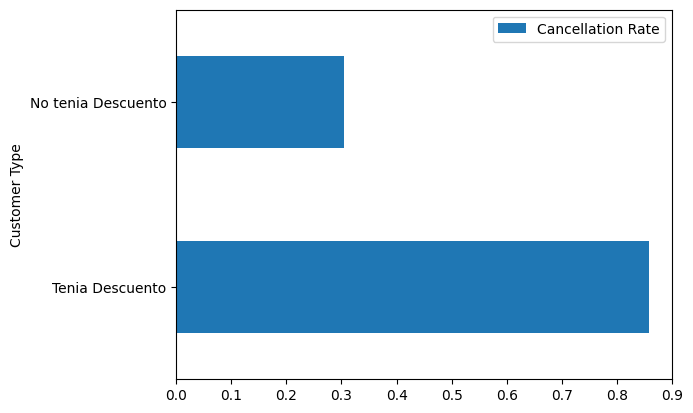

In [47]:
# Visualizacion de la tasa de cancelación para aquellos con descuento frente a aquellos sin descuento.
pd.DataFrame([['Tenia Descuento', 0.8571428571428571],
             ['No tenia Descuento', 0.30434782608695654]],
             columns=['Customer Type', 'Cancellation Rate']).plot.barh(x='Customer Type', y='Cancellation Rate', );

Para comprender mejor el historial de escucha de los clientes:
* Combinar el historial musical y las tablas de audio.
* ¿Cuántas sesiones musicales tuvo cada cliente en los últimos 3 meses?
* ¿Cuáles fueron los géneros más populares entre los clientes?

In [48]:
display(clientes.head())
display(historico_musical.head())
display(audio.head())
display(sesion.head())

,Customer ID,Customer Name,Email,Member Since,Subscription Plan,Subscription Rate,Discount?,Cancellation Date,Cancelled
0,5001,Harmony Greene,harmonious.vibes@email.com,2023-03-13,Basic (Ads),2.99,0,NaT,0
1,5002,Aria Keys,melodious.aria@email.edu,2023-03-13,Basic (Ads),2.99,0,NaT,0
2,5004,Lyric Bell,rhythmical.lyric@email.com,2023-03-13,Basic (Ads),2.99,0,2023-06-01,1
3,5267,Rock Bassett,groovy.rock@email.com,2023-03-20,Basic (Ads),2.99,0,NaT,0
4,5338,Rhythm Dixon,beats.by.rhythm@email.edu,2023-03-20,Basic (Ads),2.99,0,NaT,0


,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


,ID,Name,Genre,Popularity
0,Song-101,Dance All Night,Pop,1
1,Song-102,Unbreakable Beat,Pop,2
2,Song-103,Sunset Boulevard,Pop,5
3,Song-104,Glowing Hearts,Pop,10
4,Song-105,Pop Rocks,Pop,52


,Session ID,Session Log In Time
0,100520,2023-03-13 18:29:00
1,100522,2023-03-13 22:15:00
2,100525,2023-03-14 10:01:00
3,100527,2023-03-13 14:14:00
4,100538,2023-03-21 12:23:00


In [49]:
# Extraer el ID en los datos de audio para que la columna pueda unirse con otras tablas.
audio_clean = pd.DataFrame(audio.ID.str.split('-').to_list()).rename(columns={0:'Type', 1:'Audio ID'})
audio_clean.head()

,Type,Audio ID
0,Song,101
1,Song,102
2,Song,103
3,Song,104
4,Song,105


In [50]:
# Agrega los nuevos campos a la tabla de audio original
audio_all = pd.concat([audio_clean, audio], axis=1)
audio_all.head()

,Type,Audio ID,ID,Name,Genre,Popularity
0,Song,101,Song-101,Dance All Night,Pop,1
1,Song,102,Song-102,Unbreakable Beat,Pop,2
2,Song,103,Song-103,Sunset Boulevard,Pop,5
3,Song,104,Song-104,Glowing Hearts,Pop,10
4,Song,105,Song-105,Pop Rocks,Pop,52


In [51]:
# Hint: Compruebe el tipo de datos del ID de audio (Audio ID) en la tabla de audio.
audio_all.dtypes

,0
Type,object
Audio ID,object
ID,object
Name,object
Genre,object
Popularity,int64


In [52]:
# Cambiar Audio ID a un tipo entero en lugar de un objeto
audio_all['Audio ID'] = audio_all['Audio ID'].astype('int')
audio_all.head()

,Type,Audio ID,ID,Name,Genre,Popularity
0,Song,101,Song-101,Dance All Night,Pop,1
1,Song,102,Song-102,Unbreakable Beat,Pop,2
2,Song,103,Song-103,Sunset Boulevard,Pop,5
3,Song,104,Song-104,Glowing Hearts,Pop,10
4,Song,105,Song-105,Pop Rocks,Pop,52


In [53]:
# Verificamos
audio_all.dtypes

,0
Type,object
Audio ID,int64
ID,object
Name,object
Genre,object
Popularity,int64


In [54]:
# Unir las tablas: historico_musical y audio
df = historico_musical.merge(audio_all, how='left', on='Audio ID')
df

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52
...,...,...,...,...,...,...,...,...,...,...
500,7579,111282,4,111,Song,Song,Song-111,Moonlit Serenade,Jazz,63
501,6588,111286,1,201,Podcast,Podcast,Podcast-201,Jokes on Jokes,Comedy,2
502,5763,111333,1,110,Song,Song,Song-110,Boss Moves,Hip Hop,28
503,5763,111333,2,108,Song,Song,Song-108,Chase the Dream,Hip Hop,4


<Axes: ylabel='Frequency'>

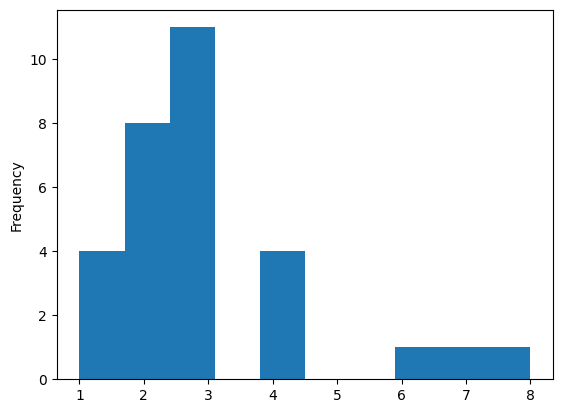

In [55]:
# Número de sesiones musicales que cada cliente tuvo en los últimos 3 meses.
df.groupby('Customer ID')['Session ID'].nunique().plot.hist()

In [56]:
# Los géneros más populares que escucharon los clientes
df.Genre.value_counts()

,count
Genre,
Pop,267
Hip Hop,88
Country,68
Jazz,48
Comedy,19
True Crime,15


## 5. Preparación para el modelo

Crea un DataFrame listo para modelar, donde cada fila represente a un cliente y contenga las siguientes columnas numéricas no nulas:
* ID del cliente (Customer ID)
* Si el cliente canceló o no (Cancelled)
* Si el cliente recibió o no un descuento (Discount?)
* Número de sesiones musicales (o de escucha)
* Porcentaje del historial musical correspondiente a música pop
* Porcentaje del historial musical correspondiente a podcasts

In [77]:
# Crea un dataframe listo para el modelado.
model_df = clientes[['Customer ID', 'Cancelled', 'Discount?']]
model_df.head()

,Customer ID,Cancelled,Discount?
0,5001,0,0
1,5002,0,0
2,5004,1,0
3,5267,0,0
4,5338,0,0


In [78]:
df.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type,Type,ID,Name,Genre,Popularity
0,5001,100520,1,101,Song,Song,Song-101,Dance All Night,Pop,1
1,5001,100520,2,102,Song,Song,Song-102,Unbreakable Beat,Pop,2
2,5001,100520,3,103,Song,Song,Song-103,Sunset Boulevard,Pop,5
3,5001,100520,4,104,Song,Song,Song-104,Glowing Hearts,Pop,10
4,5001,100520,5,105,Song,Song,Song-105,Pop Rocks,Pop,52


In [79]:
# cuántas sesiones distintas (únicas) ha tenido cada cliente
df.groupby('Customer ID')['Session ID'].nunique()

,Session ID
Customer ID,
5001,8
5002,4
5004,1
5267,7
5338,4
5404,1
5581,3
5759,2
5761,3


In [80]:
# Al codigo anterior vamos a darle formato de tabla limpia y presentable
# Calcula el número de sesiones musicales para cada cliente.
number_of_sessions = df.groupby('Customer ID')['Session ID'].nunique().rename('Number of Sessions').to_frame().reset_index()
number_of_sessions.head()

,Customer ID,Number of Sessions
0,5001,8
1,5002,4
2,5004,1
3,5267,7
4,5338,4


In [81]:
# Agregarlo al dataframe inicial (el "listo para el modelado" con las 3 primeras columnas)
model_df = model_df.merge(number_of_sessions, how='left', on='Customer ID')
model_df.head()

,Customer ID,Cancelled,Discount?,Number of Sessions
0,5001,0,0,8
1,5002,0,0,4
2,5004,1,0,1
3,5267,0,0,7
4,5338,0,0,4


**how='left'**: Esta es la regla de oro del cruce. Un Left Join (Unión Izquierda) significa:


> "Mantén TODAS las filas de mi tabla original (model_df), sin importar qué pase, si encuentras a ese cliente en la tabla number_of_sessions, pégale su número de sesiones al lado, si no lo encuentras, no borres al cliente, simplemente ponle un valor nulo (NaN) en esa columna."

In [82]:
df.Genre

,Genre
0,Pop
1,Pop
2,Pop
3,Pop
4,Pop
...,...
500,Jazz
501,Comedy
502,Hip Hop
503,Hip Hop


In [83]:
# # Calcular variables Dummy para cada género
pd.get_dummies(df.Genre, dtype = int)

,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0
...,...,...,...,...,...,...
500,0,0,0,1,0,0
501,1,0,0,0,0,0
502,0,0,1,0,0,0
503,0,0,1,0,0,0


In [84]:
# Combínar con Customer ID
pd.concat([df['Customer ID'], pd.get_dummies(df.Genre, dtype = int)], axis=1)

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,0,0,1,0
1,5001,0,0,0,0,1,0
2,5001,0,0,0,0,1,0
3,5001,0,0,0,0,1,0
4,5001,0,0,0,0,1,0
...,...,...,...,...,...,...,...
500,7579,0,0,0,1,0,0
501,6588,1,0,0,0,0,0
502,5763,0,0,1,0,0,0
503,5763,0,0,1,0,0,0


In [85]:
# Agruparlo por cliente (Customer ID)
genres = pd.concat([df['Customer ID'], pd.get_dummies(df.Genre)], axis=1).groupby('Customer ID').sum().reset_index()
genres.head()

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime
0,5001,0,0,26,0,34,0
1,5002,0,22,0,0,0,0
2,5004,0,0,0,0,9,0
3,5267,0,0,22,0,23,0
4,5338,0,18,0,0,0,0


In [86]:
historico_musical.head()

,Customer ID,Session ID,Audio Order,Audio ID,Audio Type
0,5001,100520,1,101,Song
1,5001,100520,2,102,Song
2,5001,100520,3,103,Song
3,5001,100520,4,104,Song
4,5001,100520,5,105,Song


In [87]:
# Agregar una columna para el total de canciones/podcasts escuchados
total_audio = historico_musical.groupby('Customer ID')['Audio ID'].count().rename('Total Audio').to_frame().reset_index()
total_audio.head()

,Customer ID,Total Audio
0,5001,60
1,5002,22
2,5004,9
3,5267,45
4,5338,18


In [88]:
# Crea una tabla maestra de audio para calcular porcentajes
df_audio = genres.merge(total_audio, how='left', on='Customer ID')
df_audio

,Customer ID,Comedy,Country,Hip Hop,Jazz,Pop,True Crime,Total Audio
0,5001,0,0,26,0,34,0,60
1,5002,0,22,0,0,0,0,22
2,5004,0,0,0,0,9,0,9
3,5267,0,0,22,0,23,0,45
4,5338,0,18,0,0,0,0,18
5,5404,0,0,0,0,8,0,8
6,5581,0,0,0,0,0,5,5
7,5759,0,0,0,0,15,0,15
8,5761,0,0,0,0,0,5,5
9,5763,0,0,11,0,20,0,31


In [89]:
# Porcentaje de pop
model_df['Percent Pop'] = df_audio.Pop / df_audio['Total Audio'] * 100
model_df.head()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop
0,5001,0,0,8,56.666667
1,5002,0,0,4,0.000000
2,5004,1,0,1,100.000000
3,5267,0,0,7,51.111111
4,5338,0,0,4,0.000000


In [90]:
# Porcentaje de podcasts
model_df['Percent Podcasts'] = ((df_audio['Comedy'] + df_audio['True Crime']) / df_audio['Total Audio']) * 100
model_df.head()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop,Percent Podcasts
0,5001,0,0,8,56.666667,0.0
1,5002,0,0,4,0.000000,0.0
2,5004,1,0,1,100.000000,0.0
3,5267,0,0,7,51.111111,0.0
4,5338,0,0,4,0.000000,0.0


In [91]:
model_df

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop,Percent Podcasts
0,5001,0,0,8,56.666667,0.000000
1,5002,0,0,4,0.000000,0.000000
2,5004,1,0,1,100.000000,0.000000
3,5267,0,0,7,51.111111,0.000000
4,5338,0,0,4,0.000000,0.000000
5,5404,1,0,1,100.000000,0.000000
6,5581,0,0,3,0.000000,100.000000
7,5759,1,0,2,100.000000,0.000000
8,5761,0,0,3,0.000000,100.000000
9,5763,0,0,6,64.516129,0.000000


Visualiza las relaciones en el DataFrame del modelo mediante un Pair Plot:
* ¿Cuáles son algunas de tus observaciones?

* ¿Qué variables podrían predecir con precisión la cancelación de clientes?

In [92]:
import seaborn as sns

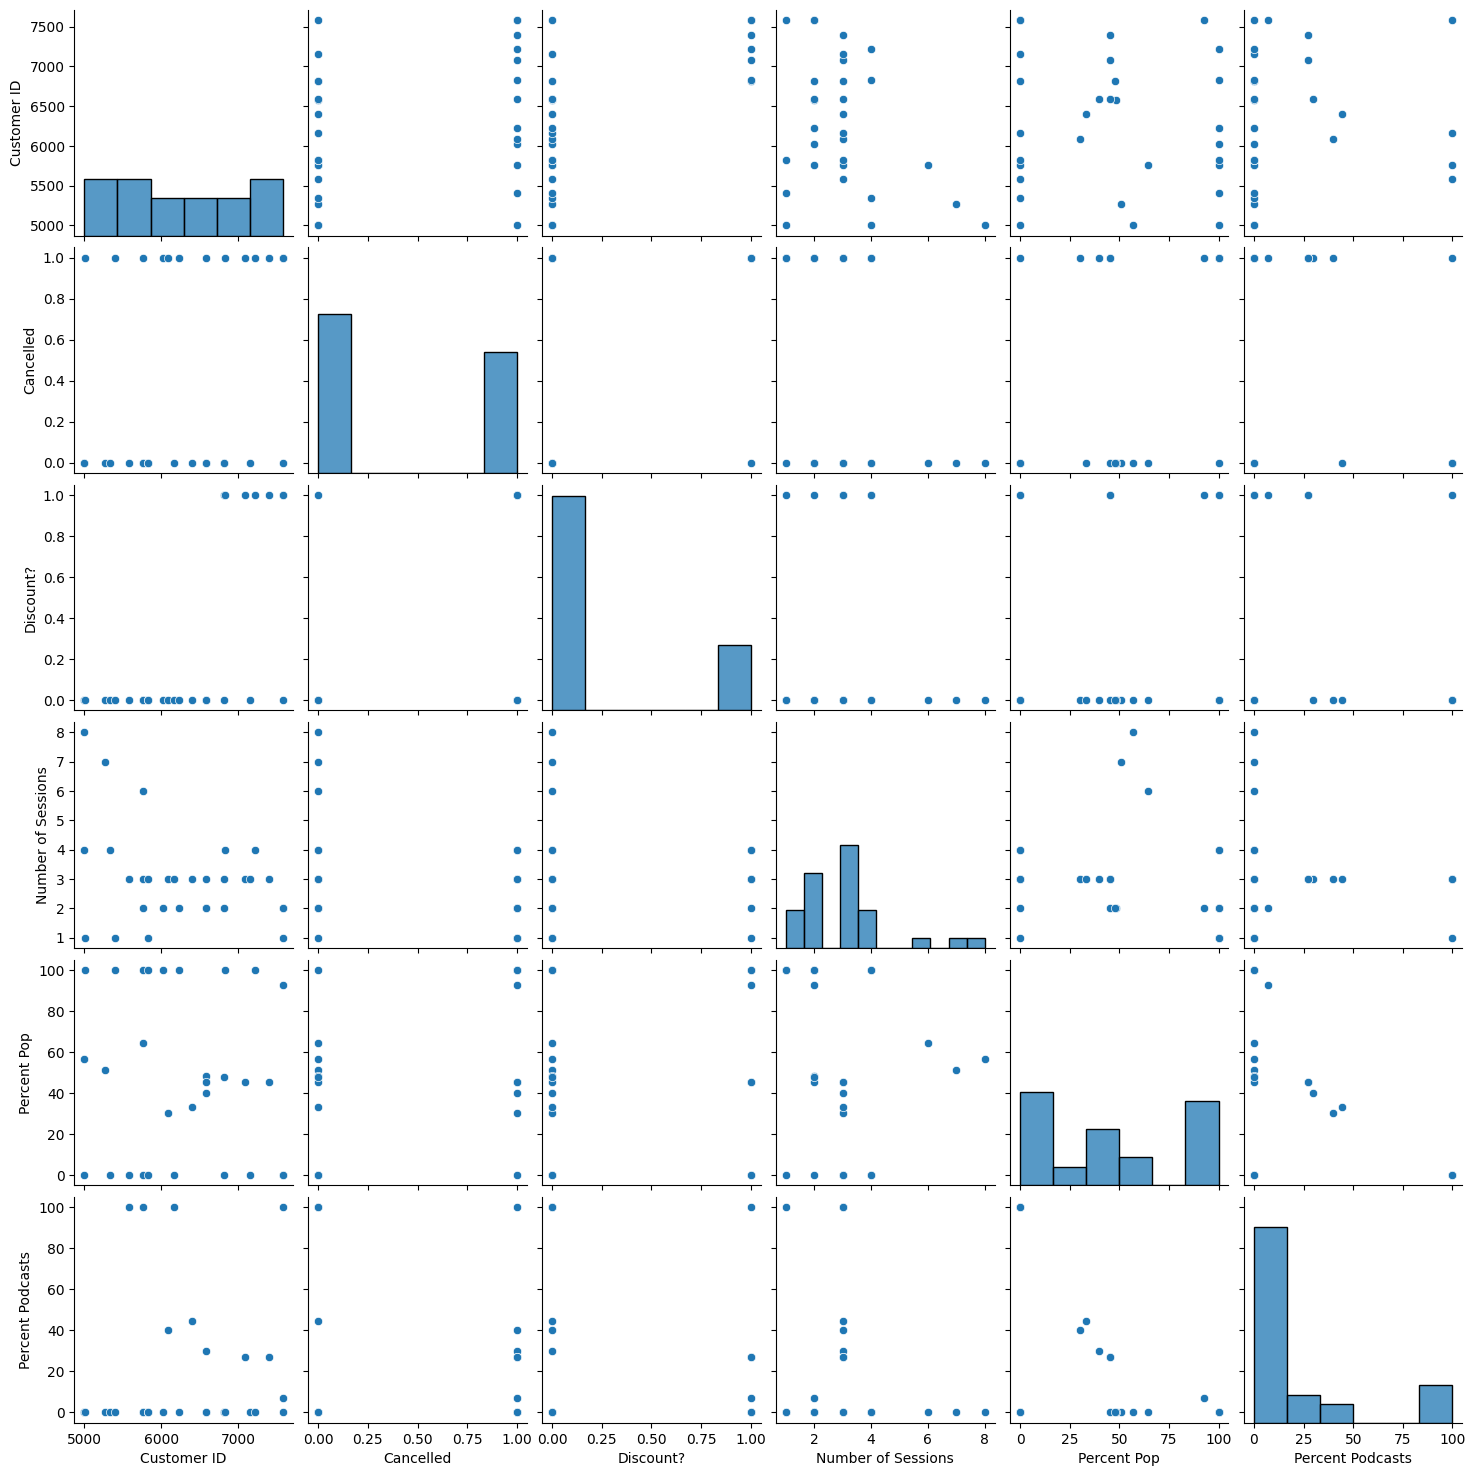

In [95]:
sns.pairplot(model_df)

#### Análisis de la Diagonal (Distribuciones Univariadas)

Los gráficos en la diagonal principal (histogramas/barras) nos muestran cómo se distribuye cada variable por sí sola:

* **Customer ID**: Muestra una distribución plana (uniforme). Esto es exactamente lo esperado para un identificador único correlativo. Nota técnica: Esta columna debe ser eliminada antes de entrenar cualquier modelo de Machine Learning, ya que no aporta valor predictivo y solo generaría ruido.

* **Cancelled** (Variable Objetivo): Es una variable binaria (0 = Activo, 1 = Cancelado). Se observa un claro desbalance de clases: la barra del 0 es mucho más alta que la del 1. Esto significa que la mayoría de los usuarios no han cancelado.

* **Discount?**: También es binaria y fuertemente desbalanceada. La inmensa mayoría de los usuarios de esta muestra no tiene un descuento aplicado.

* **Number of Sessions**: Presenta una distribución asimétrica hacia la derecha (right-skewed). La mayoría de los usuarios interactúa poco (entre 1 y 3 sesiones), y una minoría muy pequeña alcanza niveles altos de engagement (6 a 8 sesiones).

* **Percent Pop**: Tiene una distribución más dispersa, con ciertos picos en los extremos (cerca del 0% y del 100%), lo que sugiere que hay grupos de usuarios que no escuchan pop en absoluto y otros que lo escuchan de forma casi exclusiva.

* **Percent Podcasts**: Fuerte asimetría positiva. La gran barra en el 0 indica que la inmensa mayoría de los usuarios no escucha podcasts en absoluto. Solo un nicho muy pequeño consume un porcentaje alto de este formato.

#### Relaciones Clave (Gráficos de Dispersión)
Lo más interesante de un pairplot es buscar qué variables influyen en nuestra métrica principal (Cancelled). Si miramos la segunda fila (donde el eje Y es Cancelled), notamos patrones reveladores:

* Los puntos están aglomerados en el 1% principalmente. De hecho, entre los usuarios que cancelaron (Cancelled = 1), se observan puntos claramente ubicados en valores de "Percent Podcasts" mayores a cero (aproximadamente en 25%, 30%, 40% y hasta en el 100%).Hay una cantidad visible de usuarios que tenían un porcentaje de escucha de podcasts mayor a cero y de todas formas cancelaron su suscripción.

* Engagement vs. Cancelación: Cruza la fila Cancelled con la columna Number of Sessions. Los usuarios que cancelan (1) se concentran exclusivamente en el rango bajo de sesiones (1 a 4). Ningún usuario con más de 5 sesiones ha cancelado en esta muestra. A menor uso de la aplicación, mayor riesgo de fuga.

* El impacto del Descuento: Al cruzar Cancelled con Discount, vemos puntos en las cuatro esquinas, lo que indica que hay usuarios que cancelan y que se quedan en ambos grupos (con y sin descuento). A simple vista en este gráfico, el descuento no parece ser un "salvavidas" absoluto contra la cancelación, aunque requeriría un análisis estadístico más profundo para medir su impacto real.

In [98]:
# Observar las correlaciones
model_df.corr()

,Customer ID,Cancelled,Discount?,Number of Sessions,Percent Pop,Percent Podcasts
Customer ID,1.000000,0.269942,0.648514,-0.337083,-0.076129,0.083083
Cancelled,0.269942,1.000000,0.471825,-0.333739,0.585630,-0.035414
Discount?,0.648514,0.471825,1.000000,-0.048877,0.112675,0.062938
Number of Sessions,-0.337083,-0.333739,-0.048877,1.000000,-0.131156,-0.125459
Percent Pop,-0.076129,0.585630,0.112675,-0.131156,1.000000,-0.487193
Percent Podcasts,0.083083,-0.035414,0.062938,-0.125459,-0.487193,1.000000


Esta matriz de correlación (que por defecto en pandas utiliza el coeficiente de Pearson) nos revela información fascinante, especialmente si la cruzamos con lo que vimos en el pairplot anterior. Como nuestro objetivo principal es entender la fuga de clientes, vamos a centrar el análisis en la fila/columna Cancelled.

Aquí tienes los insights más importantes, ordenados desde las alertas críticas hasta las confirmaciones de negocio:

1. **La Bandera Roja (Fuga de Datos / Data Leakage):** Lo primero que salta a la vista de un ojo analítico es la columna Customer ID:

* Tiene una correlación altísima de 0.64 con Discount? y de 0.26 con Cancelled.

* ¿Por qué es peligroso? Un ID de cliente debería ser un número aleatorio o secuencial sin ningún poder predictivo. Que tenga correlación indica que los IDs no se asignaron al azar. Por ejemplo, quizás los IDs más altos (clientes más nuevos) entraron mediante una campaña masiva de descuentos.

* Acción: Debes eliminar la columna Customer ID de tu dataset antes de entrenar cualquier modelo de Machine Learning. Si la dejas, el modelo aprenderá el "ruido" de la numeración en lugar de los patrones de comportamiento reales.

2. **Los Impulsores de Fuga (Correlación Positiva con Cancelled)**
*Percent Pop (0.58): Esta es la variable de comportamiento más fuerte. Existe una relación lineal positiva bastante sólida: a mayor porcentaje de música Pop escuchada, mayor es la probabilidad de que el usuario cancele. Esto sugiere un problema de retención con este nicho específico de oyentes.

* Discount? (0.47): Un hallazgo contraintuitivo pero muy común en la industria. Tener un descuento está fuertemente correlacionado con cancelar la suscripción. Esto suele ser el clásico síntoma de los "cazadores de promociones": usuarios que crean la cuenta solo por el mes gratis o a mitad de precio, y cancelan justo antes de que se les cobre la tarifa completa.

3. **Los Impulsores de Retención (Correlación Negativa con Cancelled)**
Number of Sessions (-0.33): Una correlación negativa moderada que confirma la intuición de negocio: a mayor cantidad de sesiones (mayor engagement), menor es la probabilidad de cancelación.

4. **El "Falso Negativo" Estadístico (Podcasts)**
* Percent Podcasts (-0.035): La matriz nos dice que la correlación entre escuchar podcasts y cancelar es prácticamente cero (inexistente).

### **Conclusiones y Próximos Pasos**
Para estructurar un modelo predictivo sólido a partir de esto:

1. **Tratar el desbalance**: Dado que la mayoría de los usuarios son clase 0 en Cancelled, los modelos tenderán a predecir "0" por defecto. Será necesario aplicar técnicas como SMOTE, undersampling, o ajustar los pesos de las clases (class_weight) al entrenar el algoritmo.

2. **Feature Engineering**: El porcentaje exacto de podcasts parece menos importante que el simple hecho de si los escuchan o no. Podría ser muy útil crear una nueva variable binaria llamada Escucha_Podcasts (1 si es > 0, 0 si es 0) para darle una señal más clara y limpia al modelo.